In [33]:
from hmmlearn import hmm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from modelFuncs import *

In [34]:
#Use yfinance to download stock data for Novo Nordisk (NVO) from 2000 to 2025
#nvo_obs = dataExtracterMonths('NVO', '2000-01-01', '2025-12-31')
#nvo_obs

In [35]:
aapl_obs = dataExtracterDays('NVO', '2023-01-01', '2026-01-01').dropna()
aapl_obs

[*********************100%***********************]  1 of 1 completed

The dataset has observations across 752 days


,Date,Open,High,Low,Close
0,2023-01-03,65.229301,65.775766,64.687585,65.081993
1,2023-01-04,65.889807,65.894557,64.654311,64.991699
2,2023-01-05,64.411967,65.172266,64.331186,64.744598
3,2023-01-06,65.105756,66.075147,64.868161,65.880318
4,2023-01-09,65.927838,66.075146,65.077244,65.210297
...,...,...,...,...,...
747,2025-12-24,52.849998,53.630001,52.000000,52.560001
748,2025-12-26,53.020000,53.029999,51.700001,52.400002
749,2025-12-29,51.560001,51.990002,51.349998,51.470001
750,2025-12-30,51.520000,51.669998,51.070000,51.220001


In [36]:
aapl_data = aapl_obs[:400]
aapl_data

dates = aapl_obs['Date'][400:]
print(dates)

400    2024-08-07
401    2024-08-08
402    2024-08-09
403    2024-08-12
404    2024-08-13
          ...    
747    2025-12-24
748    2025-12-26
749    2025-12-29
750    2025-12-30
751    2025-12-31
Name: Date, Length: 352, dtype: object


In [37]:
obs = aapl_obs[aapl_obs.columns[1:5]]
print("All observations: \n", obs)

data = aapl_data[aapl_data.columns[1:5]]
print("Data from start to cut: \n", data)


All observations: 
           Open       High        Low      Close
0    65.229301  65.775766  64.687585  65.081993
1    65.889807  65.894557  64.654311  64.991699
2    64.411967  65.172266  64.331186  64.744598
3    65.105756  66.075147  64.868161  65.880318
4    65.927838  66.075146  65.077244  65.210297
..         ...        ...        ...        ...
747  52.849998  53.630001  52.000000  52.560001
748  53.020000  53.029999  51.700001  52.400002
749  51.560001  51.990002  51.349998  51.470001
750  51.520000  51.669998  51.070000  51.220001
751  51.049999  51.259998  50.549999  50.880001

[752 rows x 4 columns]
Data from start to cut: 
            Open        High         Low       Close
0     65.229301   65.775766   64.687585   65.081993
1     65.889807   65.894557   64.654311   64.991699
2     64.411967   65.172266   64.331186   64.744598
3     65.105756   66.075147   64.868161   65.880318
4     65.927838   66.075146   65.077244   65.210297
..          ...         ...         ...   

In [38]:
predict_size = len(obs)-len(data)
print("We are trying to predict the next ", predict_size, " units (e.g. days) of stock prices.")

We are trying to predict the next  352  units (e.g. days) of stock prices.


In [39]:
hmm_price, close = HMMPricePredictor(data, obs, 400, Ncomp=5)

c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


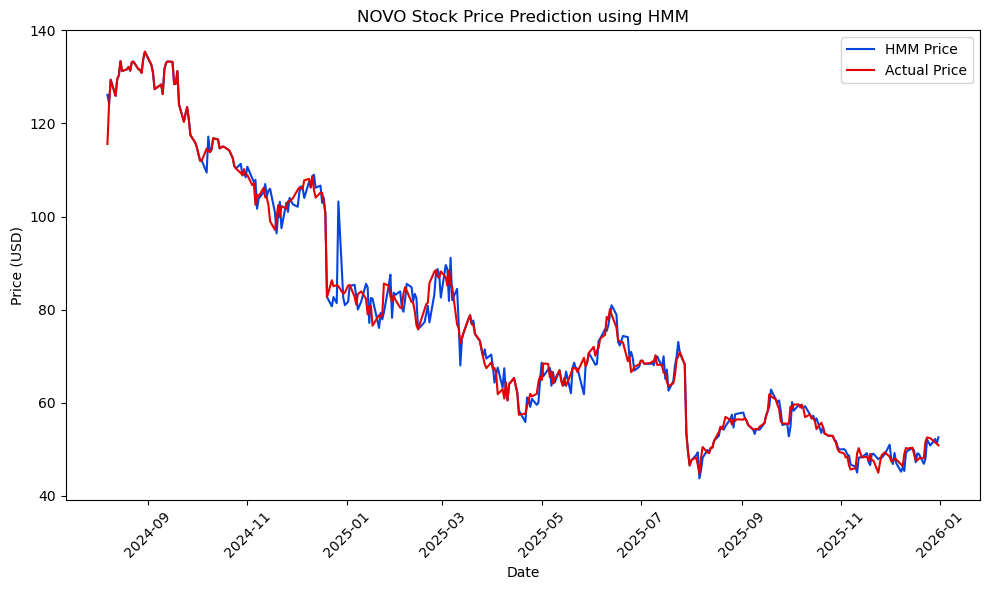

In [40]:
#Plot price against dates: 
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(dates, hmm_price, label='HMM Price', color='xkcd:blue')
ax.plot(dates, close, label='Actual Price', color='xkcd:red')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.set_title('NOVO Stock Price Prediction using HMM')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



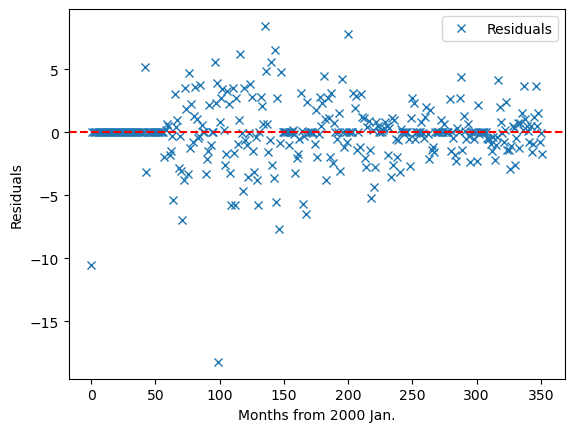

In [41]:
#Calculate residuals: 
residuals = np.array(close) - np.array(hmm_price)
fig, ax = plt.subplots()
x_vals = np.arange(len(residuals))
ax.plot(x_vals, residuals,'x', label='Residuals')
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Months from 2000 Jan.')
ax.set_ylabel('Residuals')
ax.legend();
